In [1]:
# Oncology Treatment Outcomes — Machine Learning Models
# Predicting Patient Survival Status using Logistic Regression & Random Forest
# Dataset: 450 patient records from cancer_treatment_performance_global_kpis_dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv('cancer_treatment_performance_global_kpis_dataset.csv')

print("Dataset shape:", df.shape)
print("\nSurvival Status distribution:")
print(df['Survival_Status'].value_counts())
print("\nNull values:", df.isnull().sum().sum())

Dataset shape: (450, 15)

Survival Status distribution:
Survival_Status
Alive       277
Deceased    173
Name: count, dtype: int64

Null values: 0


In [3]:
# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
features = [
    'Stage',
    'Drug_Regimen',
    'Hospital',
    'Treatment_Cost_USD',
    'Time_to_Response_Days',
    'Diagnosis',
    'Treatment_Response_Score',
    'Number_of_Cycles'
]
target = 'Survival_Status'

df_model = df[features + [target]].dropna()
df_encoded = df_model.copy()

# Encode categorical variables
le = LabelEncoder()
cat_cols = ['Stage', 'Drug_Regimen', 'Hospital', 'Diagnosis']
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_model[col])

# Encode target: Alive = 1, Deceased = 0
df_encoded[target] = (df_model[target].str.strip() == 'Alive').astype(int)

X = df_encoded[features]
y = df_encoded[target]

print(f"Total samples: {len(X)}")
print(f"Survival rate: {y.mean():.2%}")

Total samples: 450
Survival rate: 61.56%


In [4]:
# ─────────────────────────────────────────────
# 3. TRAIN/TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 360, Test size: 90


In [5]:
# ─────────────────────────────────────────────
# 4. MODEL 1 — LOGISTIC REGRESSION
# ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='f1').mean()

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy:       {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision:      {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:         {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:       {f1_score(y_test, y_pred_lr):.4f}")
print(f"CV F1 (5-fold): {lr_cv:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Deceased', 'Alive']))

LOGISTIC REGRESSION RESULTS
Accuracy:       0.6111
Precision:      0.6163
Recall:         0.9636
F1 Score:       0.7518
CV F1 (5-fold): 0.7440

              precision    recall  f1-score   support

    Deceased       0.50      0.06      0.10        35
       Alive       0.62      0.96      0.75        55

    accuracy                           0.61        90
   macro avg       0.56      0.51      0.43        90
weighted avg       0.57      0.61      0.50        90



In [6]:
# ─────────────────────────────────────────────
# 5. MODEL 2 — RANDOM FOREST
# ─────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='f1').mean()

print("RANDOM FOREST RESULTS")
print(f"Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision:      {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:         {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:       {f1_score(y_test, y_pred_rf):.4f}")
print(f"CV F1 (5-fold): {rf_cv:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Deceased', 'Alive']))

RANDOM FOREST RESULTS
Accuracy:       0.4444
Precision:      0.5362
Recall:         0.6727
F1 Score:       0.5968
CV F1 (5-fold): 0.6670

              precision    recall  f1-score   support

    Deceased       0.14      0.09      0.11        35
       Alive       0.54      0.67      0.60        55

    accuracy                           0.44        90
   macro avg       0.34      0.38      0.35        90
weighted avg       0.38      0.44      0.41        90



In [7]:
# ─────────────────────────────────────────────
# 6. MODEL COMPARISON TABLE
# ─────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 Score':  [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'CV F1 (5-fold)': [lr_cv, rf_cv]
}).round(4)

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  CV F1 (5-fold)
Logistic Regression    0.6111     0.6163  0.9636    0.7518           0.744
      Random Forest    0.4444     0.5362  0.6727    0.5968           0.667


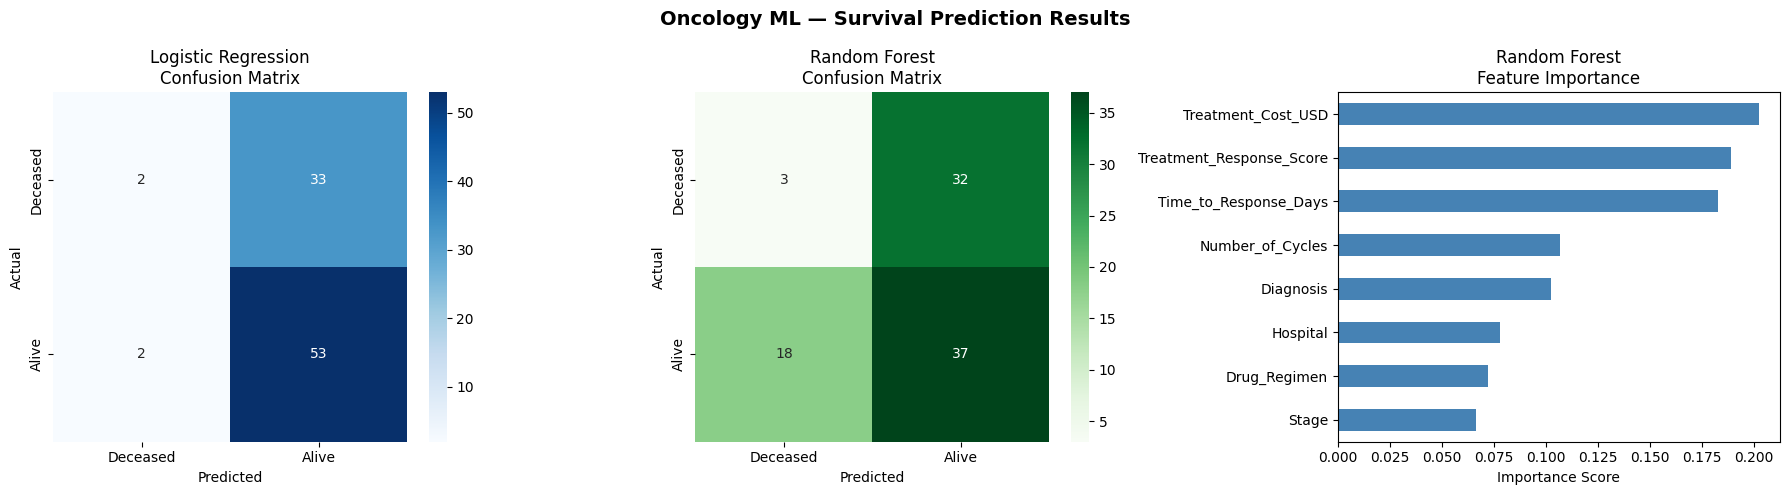

Plot saved as oncology_ml_results.png


In [8]:
# ─────────────────────────────────────────────
# 7. VISUALISATIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Oncology ML — Survival Prediction Results', fontsize=14, fontweight='bold')

# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Deceased', 'Alive'], yticklabels=['Deceased', 'Alive'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Deceased', 'Alive'], yticklabels=['Deceased', 'Alive'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

# Feature Importance — Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Random Forest\nFeature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('oncology_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as oncology_ml_results.png")